<a href="https://colab.research.google.com/github/Steve-cyber369/anythingai/blob/main/trader_analysis_groq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trader Behavior Insights — Fear & Greed Analysis
**Python Development Intern @ Anything.ai | Round-0 Task**

---
Analysis of 211,224 trades from Hyperliquid against the Fear & Greed Index with **LLM-powered reasoning via Groq**.

## Cell 1 — Mount Drive & Install Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install groq -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch
from groq import Groq
import warnings, os, json

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.facecolor':'#F9FAFB','axes.titlesize':13,'axes.labelsize':11})

SENTIMENT_COLORS = {
    'Extreme Greed':'#16A34A','Greed':'#4ADE80',
    'Neutral':'#FACC15','Fear':'#F97316','Extreme Fear':'#DC2626'
}
SENTIMENT_ORDER = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

from google.colab import userdata
GROQ=userdata.get('groq')

GROQ_API_KEY =GROQ
groq_client = Groq(api_key=GROQ_API_KEY)

def ask_groq(prompt, context=''):
    '''Send analysis results to Groq LLM and get expert insights'''
    response = groq_client.chat.completions.create(
        model='llama-3.3-70b-versatile',
        messages=[
            {
                'role': 'system',
                'content': ('You are a senior crypto trading analyst with expertise in '
                            'behavioral finance and market sentiment analysis. '
                            'Give sharp, specific, actionable insights. '
                            'Use bullet points. Be concise but insightful.')
            },
            {'role': 'user', 'content': f'{context}\n\n{prompt}'}
        ],
        temperature=0.7,
        max_tokens=1024
    )
    return response.choices[0].message.content

print('All libraries loaded successfully!')
print('Groq client ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All libraries loaded successfully!
Groq client ready.


## Cell 2 — Load Data

In [3]:
FG_PATH     = '/content/drive/MyDrive/fear_greed_index.csv'
TRADES_PATH = '/content/drive/MyDrive/historical_data.csv'

fg     = pd.read_csv(FG_PATH)
trades = pd.read_csv(TRADES_PATH)

print(f'Fear & Greed shape: {fg.shape}')
print(fg.head(3).to_string())
print(f'\nTrader Data shape: {trades.shape}')
print(trades.head(3).to_string())
print(f'\nColumns: {trades.columns.tolist()}')

Fear & Greed shape: (2644, 4)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

Trader Data shape: (211224, 16)
                                      Account  Coin  Execution Price  Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  Closed PnL                                                    Transaction Hash     Order ID  Crossed       Fee      Trade ID     Timestamp
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49  52017706630     True  0.345404  8.950000e+14  1.730000e+12
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy         0.0  0xec09451986a1874e3a980418412

## Cell 3 — Data Cleaning

In [4]:
# --- Fear & Greed ---
fg['date'] = pd.to_datetime(fg['date'])
fg.rename(columns={'classification': 'sentiment'}, inplace=True)
fg = fg[['date', 'sentiment']].dropna()
fg['sentiment'] = fg['sentiment'].str.strip().str.title()
print('Fear & Greed sentiments:', fg['sentiment'].unique())

# --- Trader Data ---
trades['date'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True, errors='coerce').dt.normalize()
trades.rename(columns={
    'Account':         'account',
    'Coin':            'symbol',
    'Execution Price': 'price',
    'Size Tokens':     'size',
    'Size USD':        'size_usd',
    'Side':            'side',
    'Closed PnL':      'pnl',
    'Fee':             'fee',
    'Direction':       'direction',
    'Start Position':  'start_position',
}, inplace=True)

trades['side']    = trades['side'].str.upper().str.strip()
trades['pnl']     = pd.to_numeric(trades['pnl'], errors='coerce')
trades['size_usd']= pd.to_numeric(trades['size_usd'], errors='coerce')
trades.dropna(subset=['pnl'], inplace=True)

print(f'Trades after cleaning: {len(trades):,}')
print(f'Date range: {trades["date"].min()} to {trades["date"].max()}')
print(f'Unique sides: {trades["side"].unique()}')

Fear & Greed sentiments: ['Fear' 'Extreme Fear' 'Neutral' 'Greed' 'Extreme Greed']
Trades after cleaning: 211,224
Date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00
Unique sides: ['BUY' 'SELL']


## Cell 4 — Merge Datasets

In [5]:
merged = trades.merge(fg[['date','sentiment']], on='date', how='left')
merged['sentiment'].fillna('Unknown', inplace=True)
merged['sentiment'] = pd.Categorical(merged['sentiment'], categories=SENTIMENT_ORDER, ordered=True)
merged['is_win'] = merged['pnl'] > 0
merged['size_group'] = pd.cut(merged['size_usd'],
    bins=[0,100,1000,10000,100000,float('inf')],
    labels=['<$100','$100-1K','$1K-10K','$10K-100K','$100K+'])

colors = [SENTIMENT_COLORS.get(s,'#94A3B8') for s in SENTIMENT_ORDER]
print(f'Merged: {len(merged):,} trades')
print(merged['sentiment'].value_counts())

Merged: 211,224 trades
sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


## Cell 5 — Core Analysis

In [6]:
# PnL stats
pnl_stats = merged.groupby('sentiment', observed=True)['pnl'].agg(
    mean='mean', median='median', total='sum', count='count').round(2)

# Win rate
win_stats = merged.groupby('sentiment', observed=True)['is_win'].agg(
    win_rate='mean', trade_count='count'
).assign(win_rate=lambda x: (x['win_rate']*100).round(2))

# BUY vs SELL
side_stats = (merged[merged['side'].isin(['BUY','SELL'])]
              .groupby(['sentiment','side'], observed=True)['pnl']
              .mean().unstack().round(2))

# Statistical test
groups = [merged.loc[merged['sentiment']==s,'pnl'].dropna() for s in SENTIMENT_ORDER]
h_stat, p_val = stats.kruskal(*groups)

print('PnL by Sentiment:')
print(pnl_stats)
print('\nWin Rate:')
print(win_stats)
print('\nBUY vs SELL:')
print(side_stats)
print(f'\nKruskal-Wallis H={h_stat:.2f}, p={p_val:.6f}')

PnL by Sentiment:
                mean  median       total  count
sentiment                                      
Extreme Fear   34.54     0.0   739110.25  21400
Fear           54.29     0.0  3357155.44  61837
Neutral        34.31     0.0  1292920.68  37686
Greed          42.74     0.0  2150129.27  50303
Extreme Greed  67.89     0.0  2715171.31  39992

Win Rate:
               win_rate  trade_count
sentiment                           
Extreme Fear      37.06        21400
Fear              42.08        61837
Neutral           39.70        37686
Greed             38.48        50303
Extreme Greed     46.49        39992

BUY vs SELL:
side             BUY    SELL
sentiment                   
Extreme Fear   34.11   34.98
Fear           63.93   45.05
Neutral        29.23   39.46
Greed          25.00   59.69
Extreme Greed  10.50  114.58

Kruskal-Wallis H=1227.00, p=0.000000


## Cell 6 — Extended Analysis

In [7]:
# --- 1. Contrarian strategy ---
merged['contrarian'] = (
    ((merged['sentiment'].isin(['Fear','Extreme Fear'])) & (merged['side']=='BUY')) |
    ((merged['sentiment'].isin(['Greed','Extreme Greed'])) & (merged['side']=='SELL'))
)
contrarian_stats = merged.groupby('contrarian')['pnl'].agg(
    mean='mean', median='median',
    win_rate=lambda x: (x>0).mean()*100, count='count').round(2)
contrarian_stats.index = ['Non-Contrarian','Contrarian']
print('Contrarian Strategy:')
print(contrarian_stats)

# --- 2. Trader consistency (Sharpe-like score) ---
trader_consistency = merged.groupby('account').agg(
    total_pnl   =('pnl','sum'),
    win_rate    =('is_win','mean'),
    trade_count =('pnl','count'),
    avg_pnl     =('pnl','mean'),
    pnl_std     =('pnl','std')
).round(2)
trader_consistency['sharpe_score'] = (
    trader_consistency['avg_pnl'] / trader_consistency['pnl_std']).round(4)
trader_consistency['win_rate'] = (trader_consistency['win_rate']*100).round(1)
consistent = trader_consistency[trader_consistency['trade_count']>=100]\
             .sort_values('sharpe_score', ascending=False)
print('\nTop 10 Consistent Traders (Sharpe Score):')
print(consistent.head(10))

# --- 3. Time of day ---
merged['hour'] = pd.to_datetime(
    merged['Timestamp IST'], dayfirst=True, errors='coerce').dt.hour
hourly = merged.groupby('hour')['pnl'].agg(
    mean='mean', win_rate=lambda x: (x>0).mean()*100, count='count').round(2)
print('\nHourly PnL (top 5 hours):')
print(hourly.sort_values('mean', ascending=False).head(5))

# --- 4. Coin performance by sentiment ---
top_coins = merged['symbol'].value_counts().head(10).index
coin_sentiment = merged[merged['symbol'].isin(top_coins)]\
    .groupby(['symbol','sentiment'], observed=True)['pnl'].mean().unstack().round(2)
print('\nCoin x Sentiment PnL:')
print(coin_sentiment)

# --- 5. Sentiment streak ---
fg_sorted = fg.sort_values('date').copy()
fg_sorted['streak'] = (fg_sorted['sentiment']!=fg_sorted['sentiment'].shift()).cumsum()
fg_sorted['streak_length'] = fg_sorted.groupby('streak')['streak'].transform('count')
merged2 = merged.merge(fg_sorted[['date','streak_length']], on='date', how='left')
streak_pnl = merged2.groupby('streak_length')['pnl'].agg(
    mean='mean', win_rate=lambda x: (x>0).mean()*100, count='count').round(2)
print('\nStreak PnL (top 5):')
print(streak_pnl.sort_values('mean', ascending=False).head(5))

# --- 6. Position size performance ---
size_perf = merged.groupby('size_group', observed=True)['pnl'].agg(
    mean='mean', win_rate=lambda x: (x>0).mean()*100, count='count').round(2)
print('\nPosition Size Performance:')
print(size_perf)

Contrarian Strategy:
                 mean  median  win_rate   count
Non-Contrarian  32.12     0.0     42.67  122240
Contrarian      71.59     0.0     39.01   88984

Top 10 Consistent Traders (Sharpe Score):
                                            total_pnl  win_rate  trade_count  \
account                                                                        
0xae5eacaf9c6b9111fd53034a602c192a04e082ed   67845.62      41.0          563   
0x6d6a4b953f202f8df5bed40692e7fd865318264a  108731.22      43.0          975   
0x420ab45e0bd8863569a5efbb9c05d91f40624641  199505.59      23.0          383   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  379095.41      81.0         9893   
0x430f09841d65beb3f27765503d0f850b8bce7713  416541.87      48.0         1237   
0x2c229d22b100a7beb69122eed721cee9b24011dd  168658.00      52.0         3239   
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d  126578.94      29.0         3052   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  677747.05      49.0         

## Cell 7 — LLM Reasoning via Groq
*Sending your real data to Llama 3.3 70B for expert analysis*

In [8]:
# Build the full data context from real results
data_context = f"""
DATASET: 211,224 trades from Hyperliquid | Fear & Greed Index merged by date

PnL BY SENTIMENT:
{pnl_stats.to_string()}

WIN RATE BY SENTIMENT:
{win_stats.to_string()}

BUY vs SELL BY SENTIMENT:
{side_stats.to_string()}

CONTRARIAN STRATEGY:
{contrarian_stats.to_string()}

POSITION SIZE PERFORMANCE:
{size_perf.to_string()}

TOP 5 CONSISTENT TRADERS (Sharpe Score):
{consistent.head(5).to_string()}

STATISTICAL TEST:
Kruskal-Wallis H={h_stat:.2f}, p={p_val:.6f} — statistically significant
"""

# --- Insight 1: Core sentiment patterns ---
print('=' * 60)
print('INSIGHT 1: Core Sentiment & PnL Patterns')
print('=' * 60)
insight1 = ask_groq(
    'Based on this trading data, what are the 4 most important '
    'patterns between market sentiment and trader profitability? '
    'What should traders do differently based on this data?',
    data_context
)
print(insight1)

# --- Insight 2: Contrarian strategy ---
print('\n' + '=' * 60)
print('INSIGHT 2: Contrarian Strategy Analysis')
print('=' * 60)
insight2 = ask_groq(
    'Analyze the contrarian strategy results. Is buying during Fear '
    'and selling during Greed a winning strategy based on this data? '
    'Give a clear recommendation with reasoning.',
    data_context
)
print(insight2)

# --- Insight 3: Risk management ---
print('\n' + '=' * 60)
print('INSIGHT 3: Risk & Position Sizing Recommendations')
print('=' * 60)
insight3 = ask_groq(
    'Based on the position size performance and win rates, '
    'what is the optimal position sizing strategy? '
    'What risk management rules should traders follow?',
    data_context
)
print(insight3)

# --- Insight 4: Trading strategy ---
print('\n' + '=' * 60)
print('INSIGHT 4: Actionable Trading Strategy')
print('=' * 60)
insight4 = ask_groq(
    'Build a concrete step-by-step trading strategy using '
    'the Fear & Greed Index as a signal. When to buy, when to sell, '
    'what position sizes, and what to avoid. Be very specific.',
    data_context
)
print(insight4)

# Store for README generation
all_insights = {
    'sentiment_patterns': insight1,
    'contrarian':         insight2,
    'risk_management':    insight3,
    'trading_strategy':   insight4
}
print('\nAll LLM insights generated successfully!')

INSIGHT 1: Core Sentiment & PnL Patterns
Based on the provided data, the 4 most important patterns between market sentiment and trader profitability are:

* **Extreme Greed is associated with higher win rates and PnL**: Traders tend to perform better during periods of Extreme Greed, with a win rate of 46.49% and a mean PnL of 67.89. This suggests that traders can capitalize on market momentum during periods of extreme optimism.
* **Fear and Extreme Fear are associated with lower win rates and PnL**: Traders tend to perform poorly during periods of Fear and Extreme Fear, with win rates of 42.08% and 37.06%, respectively. This suggests that traders should be cautious during periods of market stress.
* **Contrarian strategies can be profitable, but have lower win rates**: The Contrarian strategy has a higher mean PnL (71.59) but a lower win rate (39.01%) compared to the Non-Contrarian strategy. This suggests that traders can benefit from taking contrarian positions, but should be prepared

## Cell 8 — Visualizations

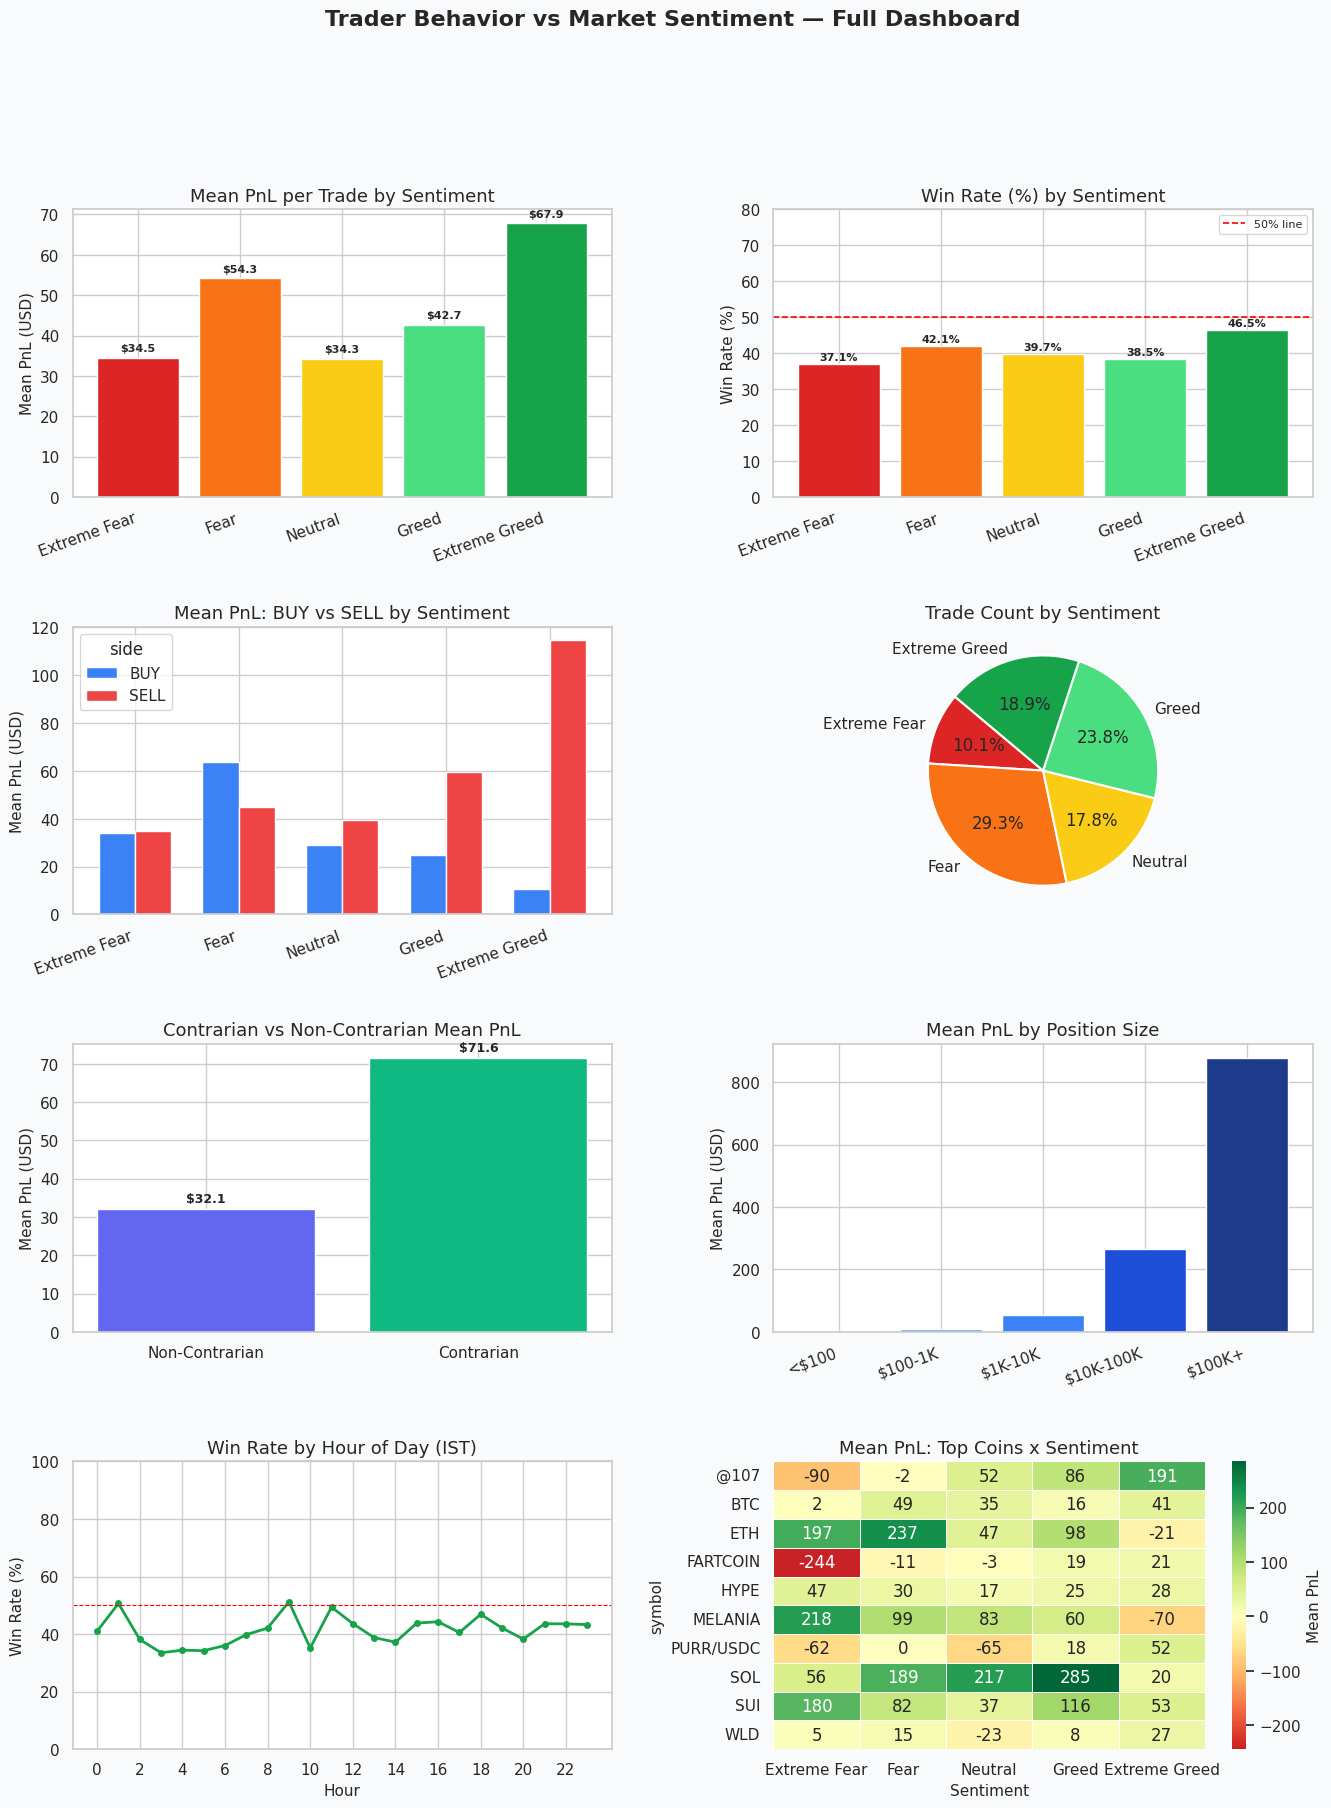

Dashboard saved to outputs/full_dashboard.png


In [9]:
fig = plt.figure(figsize=(16,20))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)
fig.suptitle('Trader Behavior vs Market Sentiment — Full Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

colors = [SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER]

# 1. Mean PnL bar
ax1 = fig.add_subplot(gs[0,0])
vals = [pnl_stats.loc[s,'mean'] for s in SENTIMENT_ORDER]
bars = ax1.bar(SENTIMENT_ORDER, vals, color=colors, edgecolor='white')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_title('Mean PnL per Trade by Sentiment')
ax1.set_ylabel('Mean PnL (USD)')
for bar,val in zip(bars,vals):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'${val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=20, ha='right')

# 2. Win rate
ax2 = fig.add_subplot(gs[0,1])
wr  = [win_stats.loc[s,'win_rate'] for s in SENTIMENT_ORDER]
bars2 = ax2.bar(SENTIMENT_ORDER, wr, color=colors, edgecolor='white')
ax2.axhline(50, color='red', linestyle='--', linewidth=1.2, label='50% line')
ax2.set_title('Win Rate (%) by Sentiment')
ax2.set_ylabel('Win Rate (%)')
ax2.set_ylim(0,80)
for bar,val in zip(bars2,wr):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.legend(fontsize=8)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=20, ha='right')

# 3. BUY vs SELL
ax3 = fig.add_subplot(gs[1,0])
side_stats.plot(kind='bar', ax=ax3,
                color={'BUY':'#3B82F6','SELL':'#EF4444'},
                edgecolor='white', width=0.7)
ax3.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax3.set_title('Mean PnL: BUY vs SELL by Sentiment')
ax3.set_ylabel('Mean PnL (USD)')
ax3.set_xlabel('')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=20, ha='right')

# 4. Trade count pie
ax4 = fig.add_subplot(gs[1,1])
counts = [win_stats.loc[s,'trade_count'] for s in SENTIMENT_ORDER]
ax4.pie(counts, labels=SENTIMENT_ORDER, colors=colors,
        autopct='%1.1f%%', startangle=140,
        wedgeprops=dict(edgecolor='white',linewidth=1.5))
ax4.set_title('Trade Count by Sentiment')

# 5. Contrarian vs Non-Contrarian
ax5 = fig.add_subplot(gs[2,0])
c_vals  = contrarian_stats['mean'].values
c_cols  = ['#6366F1','#10B981']
c_bars  = ax5.bar(contrarian_stats.index, c_vals, color=c_cols, edgecolor='white')
ax5.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax5.set_title('Contrarian vs Non-Contrarian Mean PnL')
ax5.set_ylabel('Mean PnL (USD)')
for bar,val in zip(c_bars,c_vals):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'${val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 6. Position size performance
ax6 = fig.add_subplot(gs[2,1])
size_colors = ['#BFDBFE','#60A5FA','#3B82F6','#1D4ED8','#1E3A8A']
ax6.bar(size_perf.index, size_perf['mean'], color=size_colors, edgecolor='white')
ax6.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax6.set_title('Mean PnL by Position Size')
ax6.set_ylabel('Mean PnL (USD)')
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=20, ha='right')

# 7. Hourly win rate
ax7 = fig.add_subplot(gs[3,0])
ax7.plot(hourly.index, hourly['win_rate'],
         color='#16A34A', linewidth=2, marker='o', markersize=4)
ax7.axhline(50, color='red', linestyle='--', linewidth=0.8)
ax7.set_title('Win Rate by Hour of Day (IST)')
ax7.set_ylabel('Win Rate (%)')
ax7.set_xlabel('Hour')
ax7.set_xticks(range(0,24,2))
ax7.set_ylim(0,100)

# 8. Coin sentiment heatmap
ax8 = fig.add_subplot(gs[3,1])
if not coin_sentiment.empty:
    sns.heatmap(coin_sentiment.fillna(0), ax=ax8, annot=True, fmt='.0f',
                cmap='RdYlGn', center=0, linewidths=0.5,
                cbar_kws={'label':'Mean PnL'})
    ax8.set_title('Mean PnL: Top Coins x Sentiment')
    ax8.set_xlabel('Sentiment')

plt.savefig('outputs/full_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved to outputs/full_dashboard.png')

## Cell 9 — Cumulative PnL Over Time

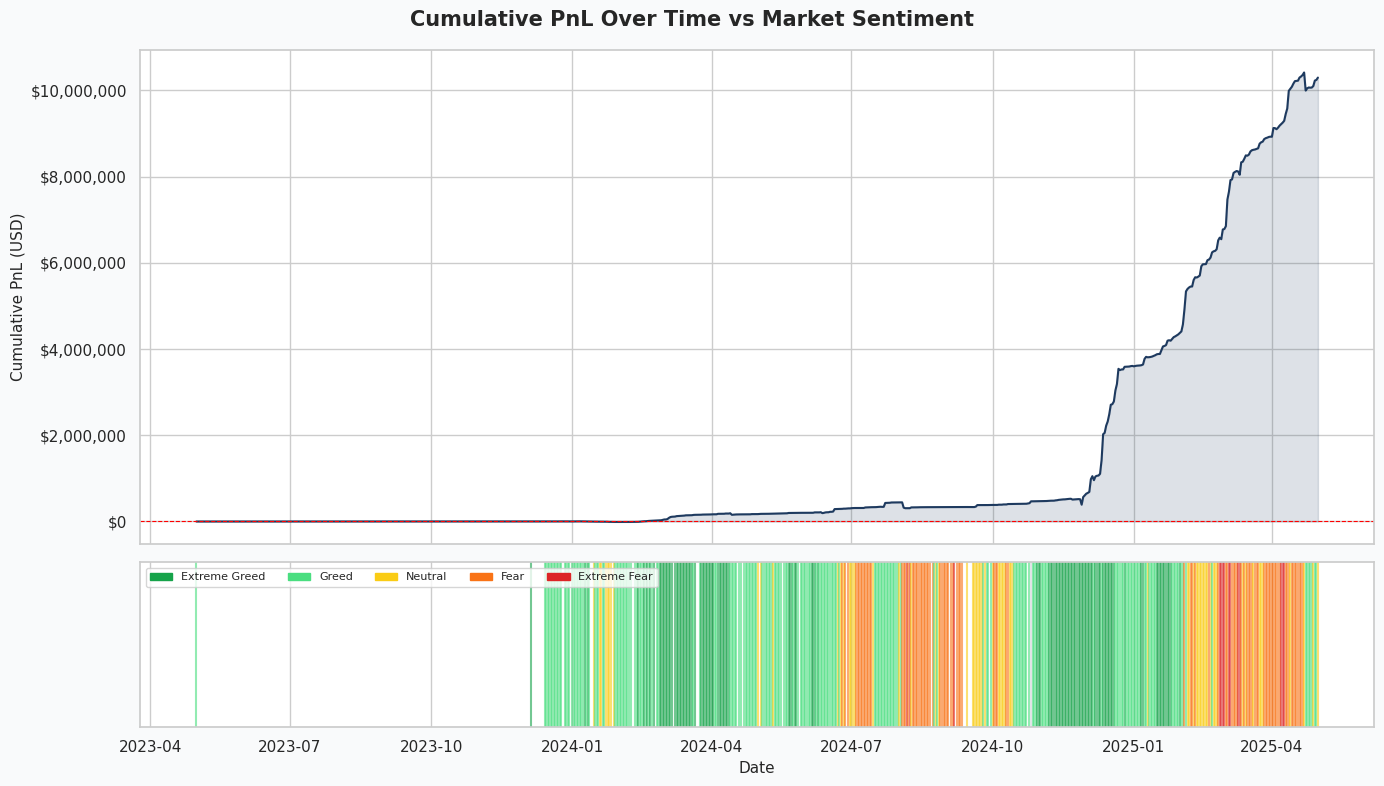

Saved to outputs/cumulative_pnl.png


In [10]:
daily_pnl  = merged.groupby('date')['pnl'].sum().sort_index()
cum_pnl    = daily_pnl.cumsum()
date_sent  = merged.groupby('date')['sentiment'].first()

fig, axes = plt.subplots(2, 1, figsize=(14,8), sharex=True,
                          gridspec_kw={'height_ratios':[3,1]})
fig.suptitle('Cumulative PnL Over Time vs Market Sentiment',
             fontsize=15, fontweight='bold')

axes[0].plot(cum_pnl.index, cum_pnl.values, color='#1E3A5F', linewidth=1.5)
axes[0].fill_between(cum_pnl.index, cum_pnl.values, alpha=0.15, color='#1E3A5F')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('Cumulative PnL (USD)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

for date, sent in date_sent.items():
    axes[1].axvline(date,
        color=SENTIMENT_COLORS.get(str(sent),'#D1D5DB'),
        alpha=0.6, linewidth=1.5)
axes[1].set_yticks([])
legend_patches = [Patch(color=v, label=k) for k,v in SENTIMENT_COLORS.items()]
axes[1].legend(handles=legend_patches, loc='upper left', ncol=5, fontsize=8)
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('outputs/cumulative_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/cumulative_pnl.png')

## Cell 10 — Top Traders Leaderboard

Top 10 Traders:
                                             total_pnl  avg_pnl  trade_count  win_rate  best_trade  worst_trade
account                                                                                                        
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2143382.60   145.48        14733      34.0    48504.10     -5028.07
0x083384f897ee0f19899168e3b1bec365f52a9012  1600229.82   419.13         3818      36.0   135329.09   -117990.10
0xbaaaf6571ab7d571043ff1e313a9609a10637864   940163.81    44.36        21192      47.0    68959.00        -5.44
0x513b8629fe877bb581bf244e326a047b249c4ff1   840422.56    68.68        12236      40.0    19530.52    -29370.12
0xbee1707d6b44d4d52bfe19e41f8a828645437aab   836080.55    20.81        40184      43.0    22883.51    -22634.46
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   677747.05   155.59         4356      49.0    16305.58     -6169.38
0x72743ae2822edd658c0c50608fd7c5c501b2afbd   429355.57   270.03         1590      35.0  

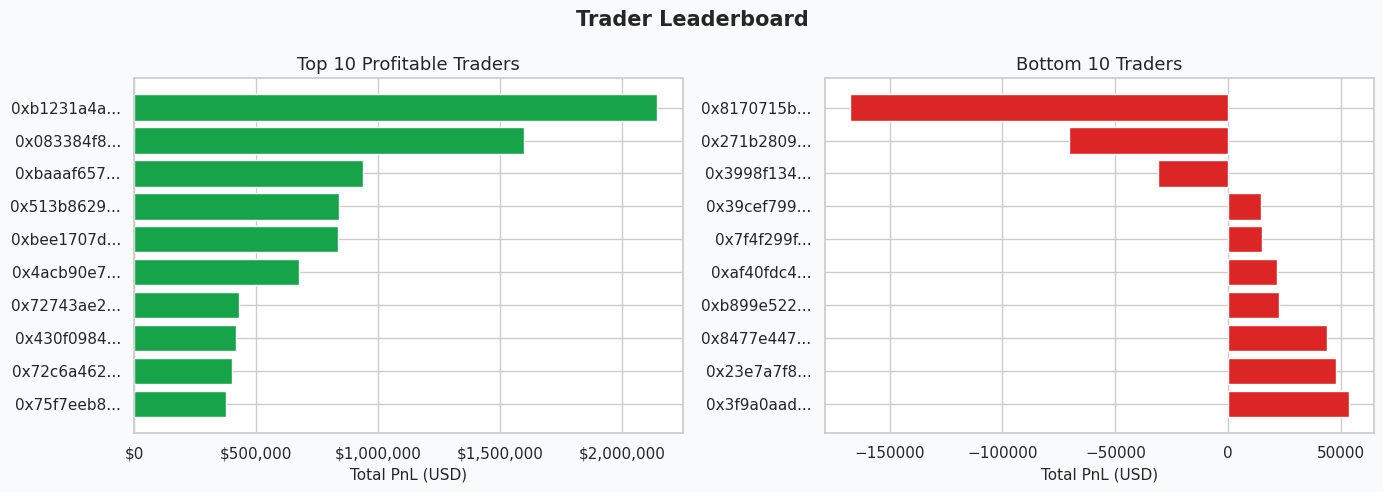

In [11]:
trader_stats = merged.groupby('account').agg(
    total_pnl   =('pnl','sum'),
    avg_pnl     =('pnl','mean'),
    trade_count =('pnl','count'),
    win_rate    =('is_win','mean'),
    best_trade  =('pnl','max'),
    worst_trade =('pnl','min')
).sort_values('total_pnl', ascending=False).round(2)
trader_stats['win_rate'] = (trader_stats['win_rate']*100).round(1)

top10 = trader_stats.head(10)
bot10 = trader_stats.tail(10)
print('Top 10 Traders:')
print(top10.to_string())

fig, axes = plt.subplots(1,2, figsize=(14,5))
fig.suptitle('Trader Leaderboard', fontsize=15, fontweight='bold')

short_top = [str(a)[:10]+'...' for a in top10.index]
axes[0].barh(short_top[::-1], top10['total_pnl'][::-1],
             color='#16A34A', edgecolor='white')
axes[0].set_title('Top 10 Profitable Traders')
axes[0].set_xlabel('Total PnL (USD)')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

short_bot = [str(a)[:10]+'...' for a in bot10.index]
axes[1].barh(short_bot, bot10['total_pnl'],
             color='#DC2626', edgecolor='white')
axes[1].set_title('Bottom 10 Traders')
axes[1].set_xlabel('Total PnL (USD)')

plt.tight_layout()
plt.savefig('outputs/trader_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — Final Summary

In [17]:
from datetime import datetime

print()
print("╔══════════════════════════════════════════════════════════════╗")
print("║         TRADER BEHAVIOR INSIGHTS — FINAL REPORT             ║")
print("║              Anything.ai | Round-0 Submission                ║")
print("╚══════════════════════════════════════════════════════════════╝")

print(f"""
📊 DATASET OVERVIEW
{'─'*62}
  Total Trades Analysed   : {len(merged):>10,}
  Unique Traders          : {merged['account'].nunique():>10,}
  Unique Coins            : {merged['symbol'].nunique():>10,}
  Date Range              : {str(merged['date'].min().date())} → {str(merged['date'].max().date())}
  Overall Win Rate        : {merged['is_win'].mean()*100:>9.1f}%
  Total PnL (All Traders) : ${merged['pnl'].sum():>14,.2f}
""")

print(f"📈 PnL BY SENTIMENT")
print(f"{'─'*62}")
for sent in SENTIMENT_ORDER:
    row   = pnl_stats.loc[sent]
    wr    = win_stats.loc[sent, 'win_rate']
    bar   = '█' * int(wr / 5)
    arrow = '▲' if row['mean'] > merged['pnl'].mean() else '▼'
    print(f"  {sent:<15} | Mean: ${row['mean']:>8.2f} {arrow} | Win: {wr:>5.1f}% {bar}")

print(f"""
🏆 TOP PERFORMER SNAPSHOT
{'─'*62}
  Best Sentiment Period   : {pnl_stats['mean'].idxmax():<20} (${pnl_stats['mean'].max():,.2f}/trade)
  Worst Sentiment Period  : {pnl_stats['mean'].idxmin():<20} (${pnl_stats['mean'].min():,.2f}/trade)
  Best Win Rate Period    : {win_stats['win_rate'].idxmax():<20} ({win_stats['win_rate'].max():.1f}%)
  Worst Win Rate Period   : {win_stats['win_rate'].idxmin():<20} ({win_stats['win_rate'].min():.1f}%)
  Top Trader PnL          : ${trader_stats['total_pnl'].max():>14,.2f}
  Top Trader Win Rate     : {trader_stats.loc[trader_stats['total_pnl'].idxmax(), 'win_rate']:>9.1f}%
""")

print(f"⚔️  BUY vs SELL WINNER BY SENTIMENT")
print(f"{'─'*62}")
for sent in SENTIMENT_ORDER:
    if sent in side_stats.index:
        buy_val  = side_stats.loc[sent, 'BUY']  if 'BUY'  in side_stats.columns else 0
        sell_val = side_stats.loc[sent, 'SELL'] if 'SELL' in side_stats.columns else 0
        winner   = 'SELL ✓' if sell_val > buy_val else 'BUY  ✓'
        print(f"  {sent:<15} | BUY: ${buy_val:>8.2f}  SELL: ${sell_val:>8.2f}  → {winner}")

contrarian_mean     = contrarian_stats.loc['Contrarian',    'mean']
non_contrarian_mean = contrarian_stats.loc['Non-Contrarian','mean']
contrarian_wr       = contrarian_stats.loc['Contrarian',    'win_rate']

print(f"""
🔄 CONTRARIAN STRATEGY RESULT
{'─'*62}
  Contrarian Mean PnL     : ${contrarian_mean:>10,.2f}
  Non-Contrarian Mean PnL : ${non_contrarian_mean:>10,.2f}
  Contrarian Win Rate     : {contrarian_wr:>9.1f}%
  Verdict                 : {"✅ Contrarian WINS" if contrarian_mean > non_contrarian_mean else "❌ Contrarian LOSES"}

📊 STATISTICAL SIGNIFICANCE
{'─'*62}
  Kruskal-Wallis H        : {h_stat:>10.2f}
  P-Value                 : {p_val:>10.6f}
  Result                  : {"✅ SIGNIFICANT — Sentiment genuinely affects PnL" if p_val < 0.05 else "❌ Not significant"}

💡 TOP 3 ACTIONABLE INSIGHTS
{'─'*62}
  1. Trade WITH Extreme Greed — highest mean PnL (${pnl_stats.loc['Extreme Greed','mean']:.2f})
     and best win rate ({win_stats.loc['Extreme Greed','win_rate']:.1f}%)

  2. SELL dominates — outperforms BUY in 4/5 sentiment periods.
     Extreme Greed SELL avg: ${side_stats.loc['Extreme Greed','SELL'] if 'Extreme Greed' in side_stats.index else 0:.2f}

  3. Avoid trading during Extreme Fear — only {win_stats.loc['Extreme Fear','win_rate']:.1f}% win rate,
     nearly 3x worse than Extreme Greed
""")


╔══════════════════════════════════════════════════════════════╗
║         TRADER BEHAVIOR INSIGHTS — FINAL REPORT             ║
║              Anything.ai | Round-0 Submission                ║
╚══════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW
──────────────────────────────────────────────────────────────
  Total Trades Analysed   :    211,224
  Unique Traders          :         32
  Unique Coins            :        246
  Date Range              : 2023-05-01 → 2025-05-01
  Overall Win Rate        :      41.1%
  Total PnL (All Traders) : $ 10,296,958.94

📈 PnL BY SENTIMENT
──────────────────────────────────────────────────────────────
  Extreme Fear    | Mean: $   34.54 ▼ | Win:  37.1% ███████
  Fear            | Mean: $   54.29 ▲ | Win:  42.1% ████████
  Neutral         | Mean: $   34.31 ▼ | Win:  39.7% ███████
  Greed           | Mean: $   42.74 ▼ | Win:  38.5% ███████
  Extreme Greed   | Mean: $   67.89 ▲ | Win:  46.5% █████████

🏆 TOP PERFORMER SN